# TAHAP SAMPLE DAN EXPLORE

In [1]:
import pandas as pd
import glob
import os

# Hubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Baca seluruh berkas CSV hasil scraping dari folder Tweet_Harvest
path_folder = '/content/drive/MyDrive/Data_TA/Dataset Tweet_Harvest/*.csv'
files = glob.glob(path_folder)

# Ambil hanya kolom full_text dari tiap berkas, lalu gabungkan
list_data = []
for file in files:
    df = pd.read_csv(file)
    if 'full_text' in df.columns:
        list_data.append(df[['full_text']].dropna())

# Gabungkan seluruh data menjadi satu dataframe
df_mentah = pd.concat(list_data, ignore_index=True)

# Simpan arsip data mentah gabungan ke Drive
df_mentah.to_excel('/content/drive/MyDrive/Data_TA/Dataset_Gabungan_TweetHarvest_Mentah.xlsx', index=False)

# Pemeriksaan kondisi data
total_data = len(df_mentah)
data_kosong = df_mentah['full_text'].isna().sum()
duplikat_eksak = df_mentah.duplicated(subset=['full_text']).sum()

print(f"Total data mentah    : {total_data} baris")
print(f"Data kosong          : {data_kosong} baris")
print(f"Duplikat eksak awal  : {duplikat_eksak} baris")

Mounted at /content/drive
Total data mentah    : 7922 baris
Data kosong          : 0 baris
Duplikat eksak awal  : 1775 baris


In [2]:
# Tampilkan contoh hasil penyaringan atribut, hanya kolom full_text
df_mentah.head(5)

,full_text
0,#makanbergizigratis #MBGuntukLansia https://t....
1,Mari sukseskan Program Makan Bergizi Gratis de...
2,Makan Bergizi Gratis: Ini 4 Mekanisme Baru Sel...
3,Transformasi Gizi Indonesia: Dari Ibu Hamil Hi...
4,Pemerintah Anggarkan Rp 80 Triliun per Kuartal...


# TAHAP MODIFY

## Cleansing
Menghapus duplikat lalu membersihkan URL, mention, hashtag, angka, dan simbol
menggunakan regular expression.

In [3]:
import re

df_modify = df_mentah.copy()

# Angka awal sebelum apa-apa
print(f"Data mentah awal              : {len(df_modify)} baris")

# Hapus duplikat eksak awal, hitung berapa yang dibuang
sebelum_dup_eksak = len(df_modify)
df_modify = df_modify.drop_duplicates(subset=['full_text']).reset_index(drop=True)
jml_dup_eksak = sebelum_dup_eksak - len(df_modify)
print(f"Duplikat eksak dibuang        : {jml_dup_eksak} baris")
print(f"Data setelah buang duplikat eksak : {len(df_modify)} baris")

# Fungsi pembersihan teks
def clean_text(teks):
    if not isinstance(teks, str):
        return ""
    teks = re.sub(r'https?://\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'@\w+', ' ', teks)
    teks = re.sub(r'#\w+', ' ', teks)
    teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)
    teks = " ".join(teks.split())
    return teks

df_modify['text_cleansed'] = df_modify['full_text'].apply(clean_text)

# Cek baris kosong setelah cleansing
sebelum_kosong = len(df_modify)
df_modify = df_modify[df_modify['text_cleansed'].str.strip() != ''].reset_index(drop=True)
jml_kosong = sebelum_kosong - len(df_modify)
print(f"Baris menjadi kosong setelah cleansing : {jml_kosong} baris")

# Buang duplikat tersembunyi yang muncul setelah cleansing
sebelum_dup_tersembunyi = len(df_modify)
df_modify = df_modify.drop_duplicates(subset=['text_cleansed']).reset_index(drop=True)
jml_dup_tersembunyi = sebelum_dup_tersembunyi - len(df_modify)
print(f"Duplikat tersembunyi dibuang  : {jml_dup_tersembunyi} baris")
print(f"Data bersih setelah cleansing : {len(df_modify)} baris")

# Contoh hasil
df_modify[['full_text', 'text_cleansed']].sample(5, random_state=1)

Data mentah awal              : 7922 baris
Duplikat eksak dibuang        : 1775 baris
Data setelah buang duplikat eksak : 6147 baris
Baris menjadi kosong setelah cleansing : 59 baris
Duplikat tersembunyi dibuang  : 1356 baris
Data bersih setelah cleansing : 4732 baris


,full_text,text_cleansed
157,"@MurtadhaOne1 Bukan sekadar program, Makan Ber...",Bukan sekadar program Makan Bergizi Gratis ada...
3725,Malam ini aku makan nasi goreng #MBG (Masakan ...,Malam ini aku makan nasi goreng Masakan Bini G...
1784,Salut sama Presiden Prabowo MBG ga cuma soal m...,Salut sama Presiden Prabowo MBG ga cuma soal m...
4573,"""Ada 62 SPPG yang kami tutup sementara karena ...",Ada SPPG yang kami tutup sementara karena tida...
3705,Program Makan Bergizi Gratis adalah investasi ...,Program Makan Bergizi Gratis adalah investasi ...


In [4]:
# Verifikasi contoh cleansing pada draf
cek = df_modify[df_modify['text_cleansed'].str.contains('Transformasi Gizi Indonesia', case=False, na=False)]
print(cek[['full_text', 'text_cleansed']].to_string())

                                                                                                                                                                           full_text                                                                  text_cleansed
2  Transformasi Gizi Indonesia: Dari Ibu Hamil Hingga Anak Sekolah Semua Terjamin! 👩‍👦🍱 ​#MakanBergiziGratis #MBG #IndonesiaSehat #KetahananPangan #bjs16516 https://t.co/eDWhfjJRht  Transformasi Gizi Indonesia Dari Ibu Hamil Hingga Anak Sekolah Semua Terjamin


## Case Folding
Mengubah seluruh huruf menjadi huruf kecil.

In [5]:
df_case_folding = df_modify.copy()

# Ubah teks menjadi huruf kecil
df_case_folding['text_case_folded'] = df_case_folding['text_cleansed'].str.lower()

# Contoh hasil
df_case_folding[['text_cleansed', 'text_case_folded']].sample(5, random_state=2)

,text_cleansed,text_case_folded
2341,MBG mewujudkan Indonesia emas,mbg mewujudkan indonesia emas
4298,Parodi rapat membahas soal menu MBG Momentum P...,parodi rapat membahas soal menu mbg momentum p...
549,Kenapa Badanmu Masih Lemas Padahal Flu nya Sud...,kenapa badanmu masih lemas padahal flu nya sud...
952,Kenyang si iya Tpi gizi nya gmna Keknya orng t...,kenyang si iya tpi gizi nya gmna keknya orng t...
505,Dua mobil Satuan Pelayanan Pemenuhan Gizi SPPG...,dua mobil satuan pelayanan pemenuhan gizi sppg...


## Tokenisasi
Memecah teks menjadi token kata menggunakan word_tokenize dari NLTK.

In [6]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

df_tokenizing = df_case_folding.copy()

# Pecah teks menjadi token
df_tokenizing['text_tokenized'] = df_tokenizing['text_case_folded'].apply(lambda x: word_tokenize(str(x)))

# Contoh hasil
df_tokenizing[['text_case_folded', 'text_tokenized']].sample(5, random_state=3)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text_case_folded,text_tokenized
1821,anak anak di ntt kini punya energi ekstra untu...,"[anak, anak, di, ntt, kini, punya, energi, eks..."
272,yang katanya orang kritik mbg gak pernah miski...,"[yang, katanya, orang, kritik, mbg, gak, perna..."
379,izin ikut diskusi walau tadi sudah sempat memb...,"[izin, ikut, diskusi, walau, tadi, sudah, semp..."
4195,sarkas template yang sama ketika ada kasus ker...,"[sarkas, template, yang, sama, ketika, ada, ka..."
1622,program makan bergizi gratis memperkuat komitm...,"[program, makan, bergizi, gratis, memperkuat, ..."


## Normalisasi
Mengubah kata tidak baku menjadi baku menggunakan kamus colloquial Indonesian
lexicon. Kata mbg dikecualikan agar tidak berubah menjadi mbak.

In [7]:
import pandas as pd

df_normalisasi = df_tokenizing.copy()

# Muat kamus dan bangun pasangan slang ke formal
df_kamus = pd.read_csv('/content/drive/MyDrive/Data_TA/colloquial-indonesian-lexicon.csv')
df_kamus = df_kamus[['slang', 'formal']].dropna().drop_duplicates(subset=['slang'])
kamus_normalisasi = dict(zip(df_kamus['slang'], df_kamus['formal']))

# Kecualikan kata mbg
if 'mbg' in kamus_normalisasi:
    del kamus_normalisasi['mbg']

# Ganti token tidak baku dengan bentuk baku
def normalisasi(tokens):
    return [kamus_normalisasi[kata] if kata in kamus_normalisasi else kata for kata in tokens]

df_normalisasi['text_normalized'] = df_normalisasi['text_tokenized'].apply(normalisasi)

# Contoh hasil yang mengalami perubahan
mask = df_normalisasi.apply(lambda r: r['text_tokenized'] != r['text_normalized'], axis=1)
df_normalisasi[mask][['text_tokenized', 'text_normalized']].sample(5, random_state=4)

,text_tokenized,text_normalized
3263,"[triliun, bukan, angka, main, main, program, m...","[triliun, bukan, angka, main, main, program, m..."
3185,"[katanya, mau, indonesia, emas, tapi, anak, an...","[katanya, mau, indonesia, emas, tapi, anak, an..."
941,"[gojek, jg, ada, kok, tapi, mungkin, skema, pe...","[gojek, juga, ada, kok, tapi, mungkin, skema, ..."
892,"[lele, mentah, masuk, paket, mbg, di, pamekasa...","[lele, mentah, masuk, paket, mbg, di, pamekasa..."
4023,"[yg, sisa, itu, mungkin, yg, keracunan, mbg]","[yang, sisa, itu, mungkin, yang, keracunan, mbg]"


In [8]:
# Cari baris spesifik contoh kedua dengan beberapa kata sekaligus
kata_cari = ['heroik', 'honorer', 'merinding', 'kudus', 'nekat']
for idx, tokens in df_normalisasi['text_tokenized'].items():
    if all(k in tokens for k in kata_cari):
        print(f"Baris index: {idx}")
        print(f"Sebelum (tokenisasi): {tokens}")
        print(f"Sesudah (normalisasi): {df_normalisasi.loc[idx, 'text_normalized']}")
        print("-" * 80)

Baris index: 25
Sebelum (tokenisasi): ['aksi', 'heroik', 'siswa', 'tolak', 'makan', 'gratis', 'dan', 'buat', 'surat', 'terbuka', 'agar', 'dananya', 'untuk', 'kesejahteraan', 'guru', 'honorer', 'saja', 'bikin', 'merinding', 'sekaligus', 'pengen', 'nangis', 'seorang', 'pelajar', 'di', 'kudus', 'nekat', 'nolak']
Sesudah (normalisasi): ['aksi', 'heroik', 'siswa', 'tolak', 'makan', 'gratis', 'dan', 'buat', 'surat', 'terbuka', 'agar', 'dananya', 'untuk', 'kesejahteraan', 'guru', 'honorer', 'saja', 'bikin', 'merinding', 'sekaligus', 'pengin', 'menangis', 'seorang', 'pelajar', 'di', 'kudus', 'nekat', 'nolak']
--------------------------------------------------------------------------------


## Stopword Removal
Menghapus kata umum menggunakan Sastrawi dan Yasirutomo. Kata negasi
diselamatkan agar polaritas sentimen tidak berubah.

In [9]:
!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

df_stopword = df_normalisasi.copy()

# Gabungkan stopword Sastrawi dan Yasirutomo
factory = StopWordRemoverFactory()
stopword_sastrawi = set(factory.get_stop_words())
with open('/content/drive/MyDrive/Data_TA/stopwordsID.txt', 'r', encoding='utf-8') as f:
    stopword_yasirutomo = set(line.strip() for line in f if line.strip())
stopword_total = stopword_sastrawi.union(stopword_yasirutomo)

# Selamatkan kata negasi
kata_negasi = {'bukan', 'tidak', 'belum', 'jangan', 'tanpa', 'kurang',
               'enggak', 'nggak', 'gak', 'tak', 'tdk'}
stopword_total = stopword_total - kata_negasi

# Hapus token yang termasuk stopword
def eksekusi_stopword(tokens):
    return [kata for kata in tokens if kata not in stopword_total]

df_stopword['text_no_stopwords'] = df_stopword['text_normalized'].apply(eksekusi_stopword)

# Contoh hasil
df_stopword[['text_normalized', 'text_no_stopwords']].sample(5, random_state=5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.6 MB/s eta 0:00:00


,text_normalized,text_no_stopwords
4097,"[kabar, keracunan, embege, hari, pertama, oper...","[kabar, keracunan, embege, operasional, kubang..."
279,"[bayu, siswa, sama, muhammadiyah, yogyakarta, ...","[bayu, siswa, muhammadiyah, yogyakarta, maaf, ..."
4301,"[req, menu, mbg, tapi, enggak, dikasih]","[req, menu, mbg, enggak, dikasih]"
4490,"[sudah, persiapan, mbg, ada, payung, hukum, mi...","[persiapan, mbg, payung, hukum, murid, mati, k..."
2323,"[prabowo, targetkan, zero, defect, mbg, mulai]","[prabowo, targetkan, zero, defect, mbg]"


## Stemming
Mengubah kata berimbuhan menjadi kata dasar menggunakan Sastrawi. Stemming
dilakukan pada kata unik untuk menghindari pengulangan proses.

In [10]:
!pip install Sastrawi -q
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

df_stemming = df_stopword.copy()

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Kumpulkan kata unik lalu stem satu kali per kata
kata_unik = set()
for tokens in df_stemming['text_no_stopwords']:
    kata_unik.update(tokens)
kamus_stem = {kata: stemmer.stem(kata) for kata in tqdm(kata_unik, desc="Stemming")}

# Terapkan hasil stemming ke seluruh data
def eksekusi_stemming(tokens):
    return [kamus_stem[kata] for kata in tokens]

df_stemming['text_stemmed'] = df_stemming['text_no_stopwords'].apply(eksekusi_stemming)

# Gabungkan token menjadi teks utuh
df_stemming['text_final'] = df_stemming['text_stemmed'].apply(lambda x: ' '.join(x))

# Buang baris yang menjadi kosong setelah stemming
sebelum_kosong = len(df_stemming)
df_stemming = df_stemming[df_stemming['text_final'].str.strip() != ''].reset_index(drop=True)
jml_kosong = sebelum_kosong - len(df_stemming)

# Buang duplikat teks final yang muncul setelah preprocessing lengkap
sebelum_dup_final = len(df_stemming)
df_stemming = df_stemming.drop_duplicates(subset=['text_final']).reset_index(drop=True)
jml_dup_final = sebelum_dup_final - len(df_stemming)

# Simpan hasil akhir preprocessing
df_stemming.to_excel('/content/drive/MyDrive/Data_TA/Hasil_Preprocessing_Final.xlsx', index=False)

print(f"Baris kosong setelah stemming dibuang : {jml_kosong} baris")
print(f"Duplikat teks final dibuang           : {jml_dup_final} baris")
print(f"Jumlah data akhir                     : {len(df_stemming)} baris")

# Contoh hasil
df_stemming[['text_no_stopwords', 'text_stemmed']].sample(5, random_state=6)

Stemming: 100%|██████████| 9052/9052 [06:05<00:00, 24.77it/s]


Baris kosong setelah stemming dibuang : 2 baris
Duplikat teks final dibuang           : 64 baris
Jumlah data akhir                     : 4666 baris


,text_no_stopwords,text_stemmed
1071,"[lauk, marinasi, mentah, menu, makan, bergizi,...","[lauk, marinasi, mentah, menu, makan, gizi, gr..."
3079,"[program, makan, bergizi, gratis, mbg, penuhi,...","[program, makan, gizi, gratis, mbg, penuh, but..."
1457,"[program, mbg, tingkatkan, kualitas, gizi, ceg...","[program, mbg, tingkat, kualitas, gizi, cegah,..."
1045,"[kreasi, menu, bergizi, pelosok, negeri, halo,...","[kreasi, menu, gizi, pelosok, negeri, halo, so..."
1774,"[zulkifli, hasan, menteri, koordinator, bidang...","[zulkifli, hasan, menteri, koordinator, bidang..."


In [11]:
# Cari baris spesifik contoh stemming pertama
kata_cari = ['program', 'makan', 'bergizi', 'gratis', 'investasi', 'jangka', 'kesehatan', 'kecerdasan', 'anak', 'indonesia']
for idx, tokens in df_stemming['text_no_stopwords'].items():
    if all(k in tokens for k in kata_cari):
        print(f"Baris index: {idx}")
        print(f"Sebelum (stopword removal): {tokens}")
        print(f"Sesudah (stemming): {df_stemming.loc[idx, 'text_stemmed']}")
        print("-" * 80)

Baris index: 2182
Sebelum (stopword removal): ['program', 'makan', 'bergizi', 'gratis', 'investasi', 'jangka', 'kesehatan', 'kecerdasan', 'anak', 'indonesia']
Sesudah (stemming): ['program', 'makan', 'gizi', 'gratis', 'investasi', 'jangka', 'sehat', 'cerdas', 'anak', 'indonesia']
--------------------------------------------------------------------------------


Word Cloud Sebelum dan Setelah Preprocessing

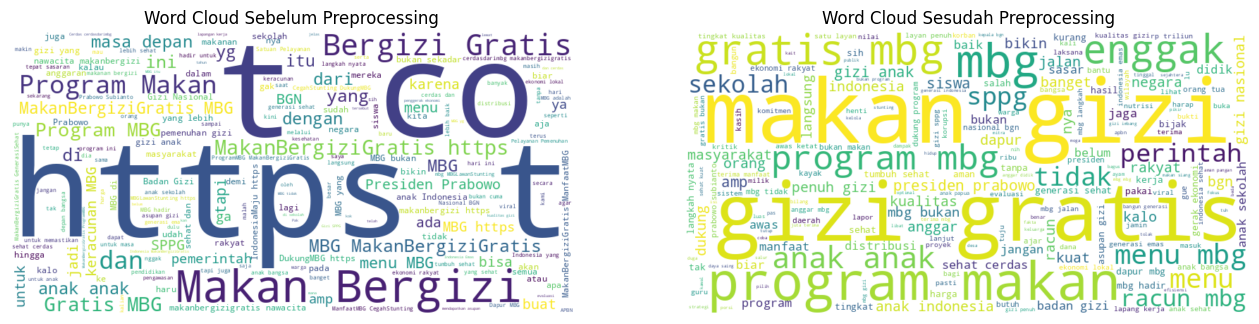

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word cloud sebelum preprocessing, dari teks mentah
teks_sebelum = ' '.join(df_stemming['full_text'].astype(str))
wc_sebelum = WordCloud(width=800, height=400, background_color='white').generate(teks_sebelum)

# Word cloud sesudah preprocessing, dari teks final
teks_sesudah = ' '.join(df_stemming['text_final'].astype(str))
wc_sesudah = WordCloud(width=800, height=400, background_color='white').generate(teks_sesudah)

# Tampilkan berdampingan
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].imshow(wc_sebelum, interpolation='bilinear')
ax[0].set_title('Word Cloud Sebelum Preprocessing')
ax[0].axis('off')
ax[1].imshow(wc_sesudah, interpolation='bilinear')
ax[1].set_title('Word Cloud Sesudah Preprocessing')
ax[1].axis('off')
plt.show()

# TAHAP MODEL

# MODEL (PELABELAN DATA)

In [13]:
import pandas as pd

# Muat dua kamus InSet
df_pos = pd.read_csv('/content/drive/MyDrive/Skripsi_Data/positive.tsv', sep='\t')
df_neg = pd.read_csv('/content/drive/MyDrive/Skripsi_Data/negative.tsv', sep='\t')

print(f"Kamus positif        : {len(df_pos)} kata")
print(f"Kamus negatif (awal) : {len(df_neg)} kata")

# Untuk kata bernilai ganda di kamus negatif, ambil polaritas paling kuat
df_neg = df_neg.sort_values('weight').drop_duplicates(subset=['word'], keep='first')

kamus_pos = dict(zip(df_pos['word'], df_pos['weight']))
kamus_neg = dict(zip(df_neg['word'], df_neg['weight']))

print(f"Kamus negatif (akhir): {len(kamus_neg)} kata")

# Hitung skor sentimen tiap tweet
def hitung_skor(teks):
    if not isinstance(teks, str) or teks.strip() == '':
        return 0
    skor_pos = 0
    skor_neg = 0
    for kata in teks.split():
        if kata in kamus_pos:
            skor_pos += kamus_pos[kata]
        if kata in kamus_neg:
            skor_neg += kamus_neg[kata]
    return skor_pos + skor_neg

# Tentukan label berdasarkan skor
def tentukan_label(skor):
    if skor > 0:
        return 'positif'
    elif skor < 0:
        return 'negatif'
    else:
        return 'netral'

# Terapkan pelabelan
df_stemming['skor_sentimen'] = df_stemming['text_final'].apply(hitung_skor)
df_stemming['label'] = df_stemming['skor_sentimen'].apply(tentukan_label)

print("\nDistribusi label:")
print(df_stemming['label'].value_counts())

# Simpan kolom penting ke Drive
kolom_simpan = ['full_text', 'text_final', 'skor_sentimen', 'label']
df_stemming[kolom_simpan].to_excel('/content/drive/MyDrive/Data_TA/Hasil_Pelabelan_Data.xlsx', index=False)

print("Hasil pelabelan tersimpan di Drive.")

Kamus positif        : 3609 kata
Kamus negatif (awal) : 6609 kata
Kamus negatif (akhir): 6607 kata

Distribusi label:
label
positif    2258
negatif    2059
netral      349
Name: count, dtype: int64
Hasil pelabelan tersimpan di Drive.


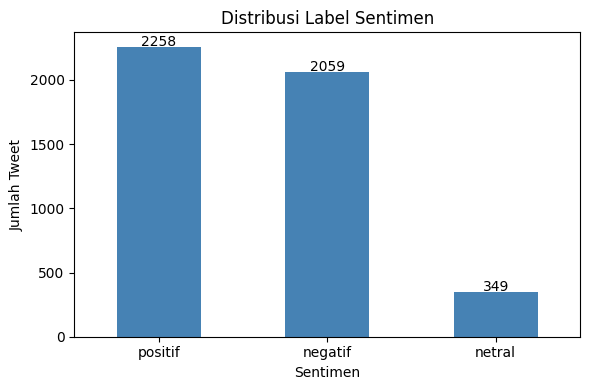

In [14]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap label
jumlah_label = df_stemming['label'].value_counts()

# Tampilkan sebagai diagram batang
plt.figure(figsize=(6, 4))
jumlah_label.plot(kind='bar', color='steelblue')
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=0)

# Tampilkan angka di atas tiap batang
for i, v in enumerate(jumlah_label):
    plt.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

rincian skor per kata sampai penjumlahan akhirnya

In [15]:
def rincian_skor(teks):
    if not isinstance(teks, str) or teks.strip() == '':
        print("(teks kosong)")
        return
    rincian = []
    total = 0
    for kata in teks.split():
        skor_kata = 0
        asal = []
        if kata in kamus_pos:
            skor_kata += kamus_pos[kata]
            asal.append(f"pos {kamus_pos[kata]:+d}")
        if kata in kamus_neg:
            skor_kata += kamus_neg[kata]
            asal.append(f"neg {kamus_neg[kata]:+d}")
        if skor_kata != 0:
            rincian.append((kata, skor_kata, " & ".join(asal)))
            total += skor_kata

    print(f"TEKS: {teks}\n")
    print(f"{'Kata':<20} | {'Skor':<6} | Asal")
    print("-" * 45)
    for kata, skor, asal in rincian:
        print(f"{kata:<20} | {skor:<+6} | {asal}")
    print("-" * 45)
    print(f"{'TOTAL SKOR':<20} | {total:<+6}")

    if total > 0:
        label = "POSITIF"
    elif total < 0:
        label = "NEGATIF"
    else:
        label = "NETRAL"
    print(f"{'LABEL':<20} | {label}")

In [16]:
rincian_skor(df_stemming['text_final'].iloc[2058])

TEKS: kritik bem ugm mbg bela rakyat cari panggung

Kata                 | Skor   | Asal
---------------------------------------------
kritik               | -5     | neg -5
cari                 | -3     | neg -3
---------------------------------------------
TOTAL SKOR           | -8    
LABEL                | NEGATIF


In [17]:
# Verifikasi contoh pelabelan
kata_cari = ['menteri', 'bangun', 'dapur', 'mbg']
for idx, teks in df_stemming['text_final'].items():
    if all(k in teks.split() for k in kata_cari):
        print(f"Baris {idx}: {teks}")
        print(f"Label: {df_stemming.loc[idx, 'label']}")
        print(f"Skor: {df_stemming.loc[idx, 'skor_sentimen'] if 'skor_sentimen' in df_stemming.columns else 'cek nama kolom skor'}")
        print("-" * 60)

Baris 403: news menteri desa bangun daerah tinggal mendes yandri susanto ingat mitra dapur program makan gizi gratis mbg jangan main main kualitas makan mark up anggar langgar sop mbg amanat negara
Label: positif
Skor: 3
------------------------------------------------------------
Baris 1082: menteri bangun dapur mbg
Label: netral
Skor: 0
------------------------------------------------------------


# MODEL (TD-IDF)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

X = df_stemming['text_final']
y = df_stemming['label']

# Inisialisasi dan transformasi TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

print(f"Jumlah dokumen : {X_tfidf.shape[0]}")
print(f"Jumlah fitur   : {X_tfidf.shape[1]}")

# Konversi ke DataFrame
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Ambil sepuluh kata dengan nilai TF-IDF tertinggi, susun jadi Top Words dan Top Values
rata_tfidf = df_tfidf.mean().sort_values(ascending=False).head(10)

df_top = pd.DataFrame({
    'Top Words': rata_tfidf.index,
    'Top Values': rata_tfidf.values.round(4)
})

print("\nKata teratas berdasarkan nilai TF-IDF:")
display(df_top)

Jumlah dokumen : 4666
Jumlah fitur   : 6575

Kata teratas berdasarkan nilai TF-IDF:


,Top Words,Top Values
0,mbg,0.0613
1,gizi,0.0608
2,makan,0.0504
3,anak,0.0498
4,program,0.0474
5,gratis,0.0395
6,indonesia,0.0281
7,sehat,0.0277
8,generasi,0.0230
9,menu,0.0213


In [19]:
# Ambil tweet pendek untuk contoh perhitungan TF-IDF
df_stemming['jumlah_kata'] = df_stemming['text_final'].apply(lambda x: len(x.split()))
tweet_pendek = df_stemming[(df_stemming['jumlah_kata'] >= 4) & (df_stemming['jumlah_kata'] <= 7)]
print(tweet_pendek[['text_final', 'jumlah_kata']].sample(15, random_state=10).to_string())

                                              text_final  jumlah_kata
1288   makan gizi gratis investasi jangka indonesia kuat            7
2299              prabowo tahan program mbg uang korupsi            6
885                              makan gizi enggak jelas            4
2587                              gizi kuat bangsa sehat            4
3262    semangat bangun tahan pangan anak anak prioritas            7
1573  bijak langkah progresif perintah perata akses gizi            7
3301                sppg masuk kampus satu riset praktik            6
2405                      mbg butuh gizi anak anak jamin            6
4134                  mati an mbg racun belas ribu orang            7
3471             program mbg ajar tunjang sehat amp ajar            7
1340                       mbg dampak ekonomi bukan gizi            5
4042                                    racun mbg lu bot            4
1625           daya ekonomi lokal efek positif bijak mbg            7
1366                

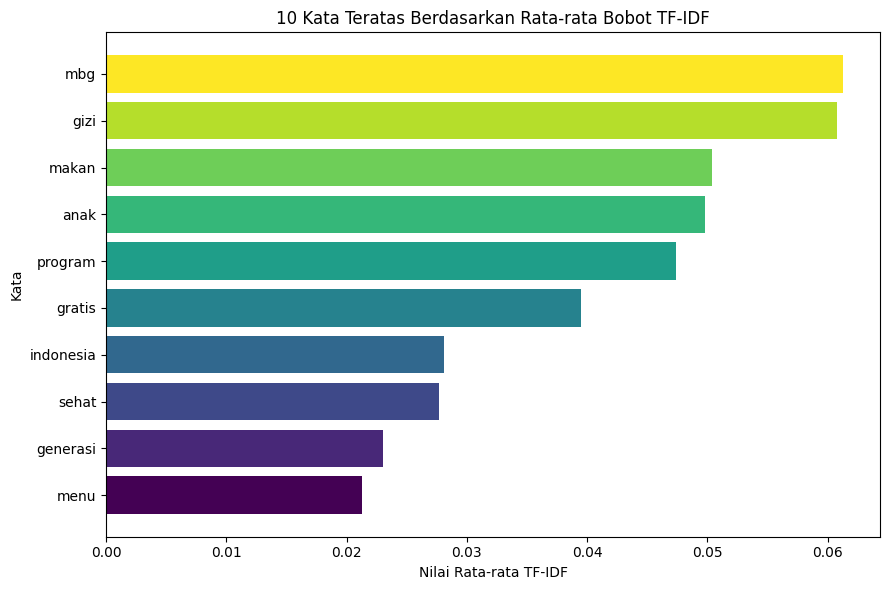

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil sepuluh kata teratas dari df_top
kata = df_top['Top Words'][::-1]
nilai = df_top['Top Values'][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(kata, nilai, color=plt.cm.viridis(np.linspace(0, 1, len(kata))))
ax.set_xlabel('Nilai Rata-rata TF-IDF')
ax.set_ylabel('Kata')
ax.set_title('10 Kata Teratas Berdasarkan Rata-rata Bobot TF-IDF')
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd

# Ambil tiga tweet contoh dari data (ganti indeks sesuai keinginan)
contoh_idx = [2587, 2405, 1340]
dokumen = [df_stemming['text_final'].iloc[i] for i in contoh_idx]

print("Dokumen contoh:")
for i, d in enumerate(dokumen):
    print(f"D{i+1}: {d}")
print()

# Kumpulkan semua kata unik dari tiga dokumen
semua_kata = sorted(set(' '.join(dokumen).split()))
N = len(dokumen)

# Hitung TF, DF, IDF, TF-IDF sesuai rumus Bab 2
hasil = []
for kata in semua_kata:
    # TF tiap dokumen = jumlah kemunculan kata / total kata dokumen
    tf_per_dok = []
    for d in dokumen:
        kata_dok = d.split()
        tf = kata_dok.count(kata) / len(kata_dok) if len(kata_dok) > 0 else 0
        tf_per_dok.append(tf)
    # DF = jumlah dokumen yang memuat kata
    df_kata = sum(1 for d in dokumen if kata in d.split())
    # IDF = log(N / df) sesuai rumus Bab 2
    idf = np.log10(N / df_kata)
    hasil.append({
        'kata': kata,
        'TF_D1': round(tf_per_dok[0], 3),
        'TF_D2': round(tf_per_dok[1], 3),
        'TF_D3': round(tf_per_dok[2], 3),
        'DF': df_kata,
        'IDF': round(idf, 3),
        'TFIDF_D1': round(tf_per_dok[0] * idf, 3),
        'TFIDF_D2': round(tf_per_dok[1] * idf, 3),
        'TFIDF_D3': round(tf_per_dok[2] * idf, 3),
    })

tabel_tfidf = pd.DataFrame(hasil)
print(tabel_tfidf.to_string(index=False))

Dokumen contoh:
D1: gizi kuat bangsa sehat
D2: mbg butuh gizi anak anak jamin
D3: mbg dampak ekonomi bukan gizi

   kata  TF_D1  TF_D2  TF_D3  DF   IDF  TFIDF_D1  TFIDF_D2  TFIDF_D3
   anak   0.00  0.333    0.0   1 0.477     0.000     0.159     0.000
 bangsa   0.25  0.000    0.0   1 0.477     0.119     0.000     0.000
  bukan   0.00  0.000    0.2   1 0.477     0.000     0.000     0.095
  butuh   0.00  0.167    0.0   1 0.477     0.000     0.080     0.000
 dampak   0.00  0.000    0.2   1 0.477     0.000     0.000     0.095
ekonomi   0.00  0.000    0.2   1 0.477     0.000     0.000     0.095
   gizi   0.25  0.167    0.2   3 0.000     0.000     0.000     0.000
  jamin   0.00  0.167    0.0   1 0.477     0.000     0.080     0.000
   kuat   0.25  0.000    0.0   1 0.477     0.119     0.000     0.000
    mbg   0.00  0.167    0.2   2 0.176     0.000     0.029     0.035
  sehat   0.25  0.000    0.0   1 0.477     0.119     0.000     0.000


# MODEL (SPLIT DATA)

In [22]:
from sklearn.model_selection import train_test_split

# Tiga rasio pembagian data: 70:30, 80:20, 90:10
rasio_uji = {'70:30': 0.3, '80:20': 0.2, '90:10': 0.1}

# Simpan hasil pembagian untuk tiap rasio
data_split = {}
for nama_rasio, ukuran_uji in rasio_uji.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y,
        test_size=ukuran_uji,
        random_state=42,
        stratify=y
    )
    data_split[nama_rasio] = (X_train, X_test, y_train, y_test)
    print(f"Rasio {nama_rasio} -> data latih: {X_train.shape[0]}, data uji: {X_test.shape[0]}")

Rasio 70:30 -> data latih: 3266, data uji: 1400
Rasio 80:20 -> data latih: 3732, data uji: 934
Rasio 90:10 -> data latih: 4199, data uji: 467


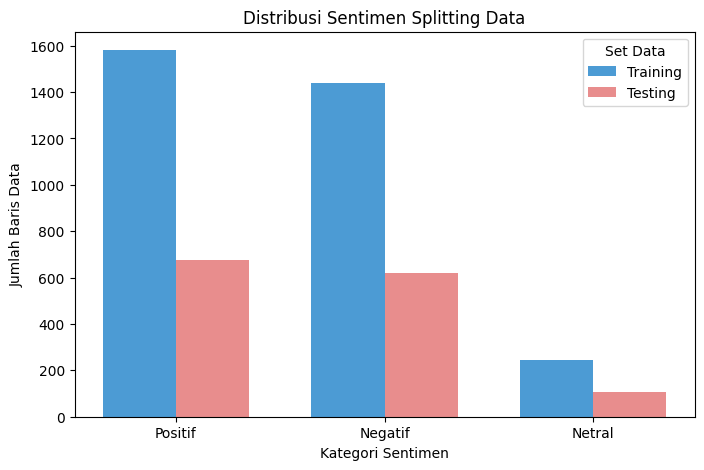

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil distribusi dari salah satu rasio, misalnya 70:30
X_train, X_test, y_train, y_test = data_split['70:30']

kelas = ['positif', 'negatif', 'netral']
jml_train = [sum(y_train == k) for k in kelas]
jml_test = [sum(y_test == k) for k in kelas]

x = np.arange(len(kelas))
lebar = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - lebar/2, jml_train, lebar, label='Training', color='#4C9BD4')
ax.bar(x + lebar/2, jml_test, lebar, label='Testing', color='#E88D8D')

ax.set_xlabel('Kategori Sentimen')
ax.set_ylabel('Jumlah Baris Data')
ax.set_title('Distribusi Sentimen Splitting Data')
ax.set_xticks(x)
ax.set_xticklabels([k.capitalize() for k in kelas])
ax.legend(title='Set Data')
plt.show()

# MODEL (KLASIFIKASI NBC)

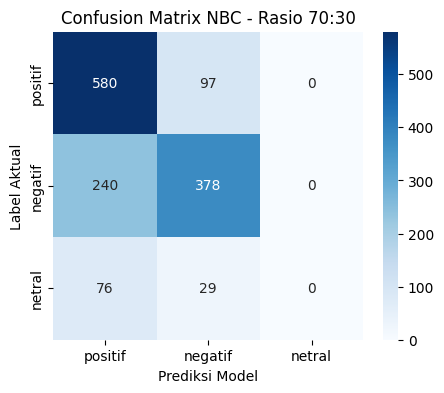

--- Classification Report NBC (70:30) ---
              precision    recall  f1-score   support

     negatif     0.7500    0.6117    0.6738       618
      netral     0.0000    0.0000    0.0000       105
     positif     0.6473    0.8567    0.7374       677

    accuracy                         0.6843      1400
   macro avg     0.4658    0.4895    0.4704      1400
weighted avg     0.6441    0.6843    0.6540      1400

------------------------------------------------------------


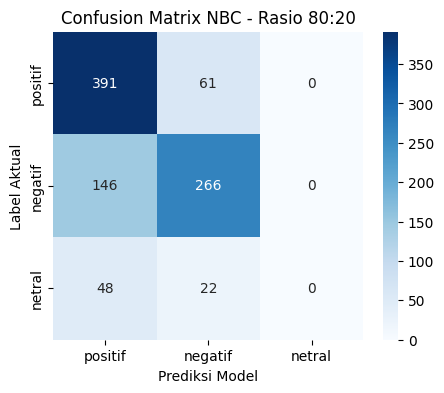

--- Classification Report NBC (80:20) ---
              precision    recall  f1-score   support

     negatif     0.7622    0.6456    0.6991       412
      netral     0.0000    0.0000    0.0000        70
     positif     0.6684    0.8650    0.7541       452

    accuracy                         0.7034       934
   macro avg     0.4769    0.5036    0.4844       934
weighted avg     0.6597    0.7034    0.6733       934

------------------------------------------------------------


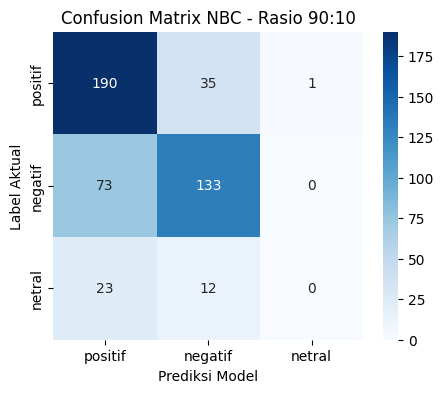

--- Classification Report NBC (90:10) ---
              precision    recall  f1-score   support

     negatif     0.7389    0.6456    0.6891       206
      netral     0.0000    0.0000    0.0000        35
     positif     0.6643    0.8407    0.7422       226

    accuracy                         0.6916       467
   macro avg     0.4677    0.4954    0.4771       467
weighted avg     0.6474    0.6916    0.6632       467

------------------------------------------------------------
RINGKASAN HASIL NBC (3 RASIO):


,Rasio,Training Time (s),Inference Time (s),Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,70:30,0.01047,0.00068,68.43,46.58,48.95,47.04
1,80:20,0.02208,0.00059,70.34,47.69,50.36,48.44
2,90:10,0.02456,0.00050,69.16,46.77,49.54,47.71


In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

label_urut = ['positif', 'negatif', 'netral']
rekap_nbc = []
hasil_nbc = {}

for nama_rasio, (X_train, X_test, y_train, y_test) in data_split.items():
    # Latih dan catat training time
    model_nbc = MultinomialNB()
    mulai = time.time()
    model_nbc.fit(X_train, y_train)
    training_time = time.time() - mulai

    # Prediksi dan catat inference time
    mulai = time.time()
    y_pred = model_nbc.predict(X_test)
    inference_time = time.time() - mulai

    hasil_nbc[nama_rasio] = {'y_test': y_test, 'y_pred': y_pred,
                             'training_time': training_time, 'inference_time': inference_time}

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=label_urut)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_urut, yticklabels=label_urut)
    plt.title(f'Confusion Matrix NBC - Rasio {nama_rasio}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Aktual')
    plt.show()

    # Classification report
    print(f"--- Classification Report NBC ({nama_rasio}) ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("-" * 60)

    # Kumpulkan untuk rekap
    rekap_nbc.append({
        'Rasio': nama_rasio,
        'Training Time (s)': round(training_time, 5),
        'Inference Time (s)': round(inference_time, 5),
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2)
    })

print("RINGKASAN HASIL NBC (3 RASIO):")
df_rekap_nbc = pd.DataFrame(rekap_nbc)
display(df_rekap_nbc)

# MODEL (KLASIFIKASI SVM)

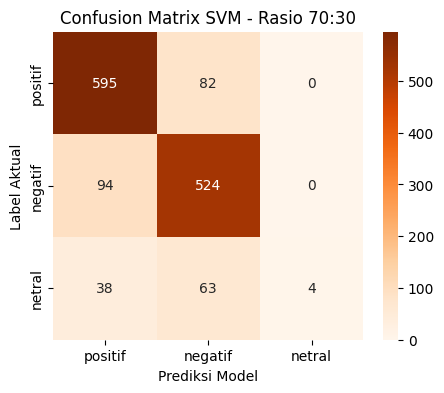

--- Classification Report SVM (70:30) ---
              precision    recall  f1-score   support

     negatif     0.7833    0.8479    0.8143       618
      netral     1.0000    0.0381    0.0734       105
     positif     0.8184    0.8789    0.8476       677

    accuracy                         0.8021      1400
   macro avg     0.8672    0.5883    0.5784      1400
weighted avg     0.8165    0.8021    0.7748      1400

------------------------------------------------------------


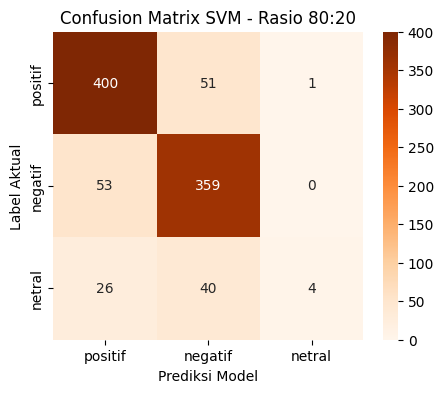

--- Classification Report SVM (80:20) ---
              precision    recall  f1-score   support

     negatif     0.7978    0.8714    0.8329       412
      netral     0.8000    0.0571    0.1067        70
     positif     0.8351    0.8850    0.8593       452

    accuracy                         0.8169       934
   macro avg     0.8110    0.6045    0.5996       934
weighted avg     0.8160    0.8169    0.7913       934

------------------------------------------------------------


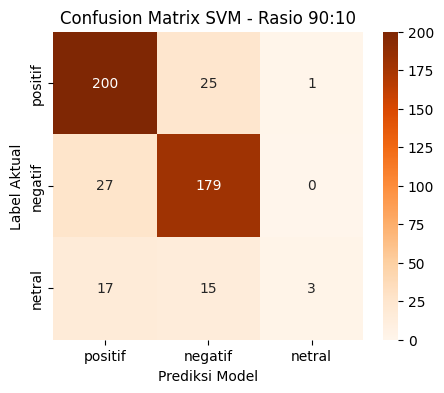

--- Classification Report SVM (90:10) ---
              precision    recall  f1-score   support

     negatif     0.8174    0.8689    0.8424       206
      netral     0.7500    0.0857    0.1538        35
     positif     0.8197    0.8850    0.8511       226

    accuracy                         0.8180       467
   macro avg     0.7957    0.6132    0.6158       467
weighted avg     0.8134    0.8180    0.7950       467

------------------------------------------------------------
RINGKASAN HASIL SVM (3 RASIO):


,Rasio,Training Time (s),Inference Time (s),Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,70:30,3.87988,0.74268,80.21,86.72,58.83,57.84
1,80:20,2.30520,0.39120,81.69,81.10,60.45,59.96
2,90:10,3.29642,0.32946,81.80,79.57,61.32,61.58


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

label_urut = ['positif', 'negatif', 'netral']
rekap_svm = []
hasil_svm = {}

for nama_rasio, (X_train, X_test, y_train, y_test) in data_split.items():
    # Latih dan catat training time
    model_svm = SVC(kernel='linear')
    mulai = time.time()
    model_svm.fit(X_train, y_train)
    training_time = time.time() - mulai

    # Prediksi dan catat inference time
    mulai = time.time()
    y_pred = model_svm.predict(X_test)
    inference_time = time.time() - mulai

    hasil_svm[nama_rasio] = {'y_test': y_test, 'y_pred': y_pred,
                             'training_time': training_time, 'inference_time': inference_time}

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=label_urut)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=label_urut, yticklabels=label_urut)
    plt.title(f'Confusion Matrix SVM - Rasio {nama_rasio}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Aktual')
    plt.show()

    # Classification report
    print(f"--- Classification Report SVM ({nama_rasio}) ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("-" * 60)

    # Kumpulkan untuk rekap
    rekap_svm.append({
        'Rasio': nama_rasio,
        'Training Time (s)': round(training_time, 5),
        'Inference Time (s)': round(inference_time, 5),
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2)
    })

print("RINGKASAN HASIL SVM (3 RASIO):")
df_rekap_svm = pd.DataFrame(rekap_svm)
display(df_rekap_svm)

analisis tambahan utnuk kernel SVM

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Ambil data dari rasio 90:10
X_train, X_test, y_train, y_test = data_split['90:10']

# Bandingkan tiga kernel
kernels = ['linear', 'rbf', 'poly']
hasil_kernel = []

for k in kernels:
    model = SVC(kernel=k)

    mulai = time.time()
    model.fit(X_train, y_train)
    waktu_latih = time.time() - mulai

    y_pred = model.predict(X_test)

    hasil_kernel.append({
        'Kernel': k,
        'Akurasi (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Training Time (s)': round(waktu_latih, 4)
    })

import pandas as pd
df_kernel = pd.DataFrame(hasil_kernel)
print("PERBANDINGAN KERNEL SVM (rasio 90:10):")
display(df_kernel)

PERBANDINGAN KERNEL SVM (rasio 90:10):


,Kernel,Akurasi (%),Precision (%),Recall (%),F1-Score (%),Training Time (s)
0,linear,81.80,79.57,61.32,61.58,2.1412
1,rbf,80.09,86.69,58.54,57.22,3.0582
2,poly,68.74,80.15,50.66,49.32,3.0780


# MODEL (VALIDASI K-FOLD)

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import time

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_array = X_tfidf
y_array = y.reset_index(drop=True)

def kfold_per_fold(model, nama_model):
    baris = []
    train_times, infer_times = [], []
    jml_latih, jml_uji = [], []
    fold_ke = 1
    for train_idx, test_idx in skf.split(X_array, y_array):
        X_train, X_test = X_array[train_idx], X_array[test_idx]
        y_train, y_test = y_array[train_idx], y_array[test_idx]

        jml_latih.append(len(train_idx))
        jml_uji.append(len(test_idx))

        mulai = time.time()
        model.fit(X_train, y_train)
        train_times.append(time.time() - mulai)

        mulai = time.time()
        y_pred = model.predict(X_test)
        infer_times.append(time.time() - mulai)

        baris.append({
            'Fold': fold_ke,
            'Akurasi (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
            'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
            'Recall (%)': round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
            'F1-Score (%)': round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2)
        })
        fold_ke += 1

    df = pd.DataFrame(baris)
    rata = {
        'Fold': 'Rata-rata',
        'Akurasi (%)': round(df['Akurasi (%)'].mean(), 2),
        'Precision (%)': round(df['Precision (%)'].mean(), 2),
        'Recall (%)': round(df['Recall (%)'].mean(), 2),
        'F1-Score (%)': round(df['F1-Score (%)'].mean(), 2)
    }
    df = pd.concat([df, pd.DataFrame([rata])], ignore_index=True)

    print(f"=== HASIL 10-FOLD CROSS VALIDATION {nama_model} ===")
    print(f"Jumlah Data Latih tiap fold : sekitar {int(np.mean(jml_latih))} data")
    print(f"Jumlah Data Uji tiap fold   : sekitar {int(np.mean(jml_uji))} data")
    print(f"Rata-rata Training Time     : {np.mean(train_times):.5f} detik")
    print(f"Rata-rata Inference Time    : {np.mean(infer_times):.5f} detik")
    display(df)
    return df, np.mean(train_times), np.mean(infer_times)

df_kfold_nbc, train_nbc, infer_nbc = kfold_per_fold(MultinomialNB(), 'NBC')
df_kfold_svm, train_svm, infer_svm = kfold_per_fold(SVC(kernel='linear'), 'SVM')

=== HASIL 10-FOLD CROSS VALIDATION NBC ===
Jumlah Data Latih tiap fold : sekitar 4199 data
Jumlah Data Uji tiap fold   : sekitar 466 data
Rata-rata Training Time     : 0.00700 detik
Rata-rata Inference Time    : 0.00028 detik


,Fold,Akurasi (%),Precision (%),Recall (%),F1-Score (%)
0,1,68.95,47.03,49.34,47.52
1,2,71.73,48.47,51.33,49.32
2,3,72.81,49.57,52.15,50.25
3,4,66.38,45.07,47.51,45.77
4,5,68.31,46.03,48.85,46.89
5,6,69.38,47.09,49.61,47.64
6,7,67.60,45.88,48.29,46.56
7,8,68.88,46.60,49.35,47.52
8,9,70.82,47.78,50.72,48.73
9,10,67.38,45.31,48.25,46.33


=== HASIL 10-FOLD CROSS VALIDATION SVM ===
Jumlah Data Latih tiap fold : sekitar 4199 data
Jumlah Data Uji tiap fold   : sekitar 466 data
Rata-rata Training Time     : 1.88986 detik
Rata-rata Inference Time    : 0.15602 detik


,Fold,Akurasi (%),Precision (%),Recall (%),F1-Score (%)
0,1,81.58,71.09,59.53,58.23
1,2,79.44,86.25,57.96,56.72
2,3,83.08,55.55,59.83,57.60
3,4,77.94,68.69,56.96,55.74
4,5,82.23,54.78,59.23,56.91
5,6,80.09,70.14,58.49,57.23
6,7,80.47,53.63,57.89,55.67
7,8,83.48,55.70,60.25,57.81
8,9,80.47,67.25,59.54,59.04
9,10,83.26,88.81,60.80,59.43


# TAHAP ASSESS

Perbandingan Kinerja NBC dan SVM

In [28]:
import pandas as pd

# Perbandingan kinerja berdasarkan hasil k-fold
perbandingan_kinerja = pd.DataFrame({
    'Algoritma': ['NBC', 'SVM'],
    'Akurasi (%)': [df_kfold_nbc.iloc[-1]['Akurasi (%)'], df_kfold_svm.iloc[-1]['Akurasi (%)']],
    'Precision (%)': [df_kfold_nbc.iloc[-1]['Precision (%)'], df_kfold_svm.iloc[-1]['Precision (%)']],
    'Recall (%)': [df_kfold_nbc.iloc[-1]['Recall (%)'], df_kfold_svm.iloc[-1]['Recall (%)']],
    'F1-Score (%)': [df_kfold_nbc.iloc[-1]['F1-Score (%)'], df_kfold_svm.iloc[-1]['F1-Score (%)']]
})

print("PERBANDINGAN KINERJA NBC DAN SVM (berdasarkan k-fold):")
display(perbandingan_kinerja)

PERBANDINGAN KINERJA NBC DAN SVM (berdasarkan k-fold):


,Algoritma,Akurasi (%),Precision (%),Recall (%),F1-Score (%)
0,NBC,69.22,46.88,49.54,47.65
1,SVM,81.20,67.19,59.05,57.44


Perbandingan Efisiensi Komputasi

In [35]:
import pandas as pd

# Perbandingan efisiensi berdasarkan hasil rata-rata k-fold
perbandingan_efisiensi = pd.DataFrame({
    'Algoritma': ['NBC', 'SVM'],
    'Training Time (s)': [round(train_nbc, 5), round(train_svm, 5)],
    'Inference Time (s)': [round(infer_nbc, 5), round(infer_svm, 5)]
})

print("PERBANDINGAN EFISIENSI KOMPUTASI NBC DAN SVM (berdasarkan k-fold):")
display(perbandingan_efisiensi)

# Hitung berapa kali SVM lebih lambat dibandingkan NBC
rasio_training = train_svm / train_nbc
rasio_inference = infer_svm / infer_nbc

print(f"\nSVM membutuhkan waktu pelatihan sekitar {rasio_training:.0f} kali lebih lama dibandingkan NBC")
print(f"SVM membutuhkan waktu prediksi sekitar {rasio_inference:.0f} kali lebih lama dibandingkan NBC")

PERBANDINGAN EFISIENSI KOMPUTASI NBC DAN SVM (berdasarkan k-fold):


,Algoritma,Training Time (s),Inference Time (s)
0,NBC,0.00700,0.00028
1,SVM,1.88986,0.15602



SVM membutuhkan waktu pelatihan sekitar 270 kali lebih lama dibandingkan NBC
SVM membutuhkan waktu prediksi sekitar 555 kali lebih lama dibandingkan NBC


Word Cloud

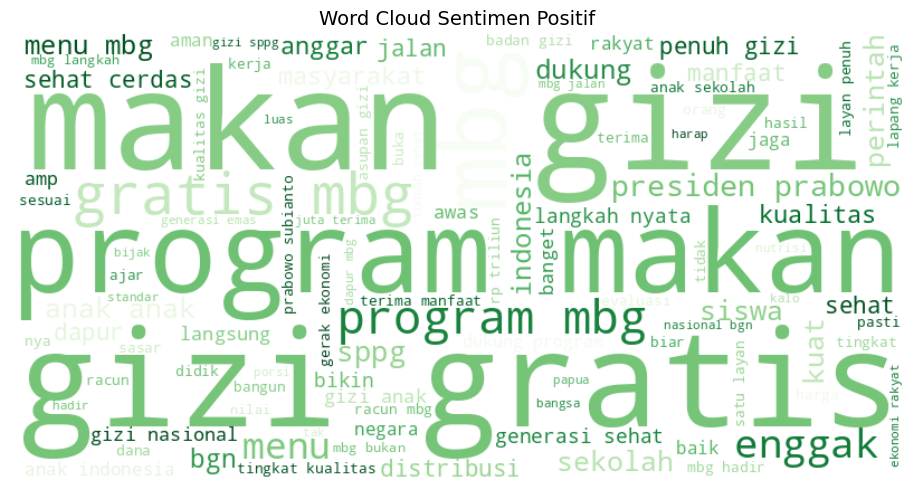

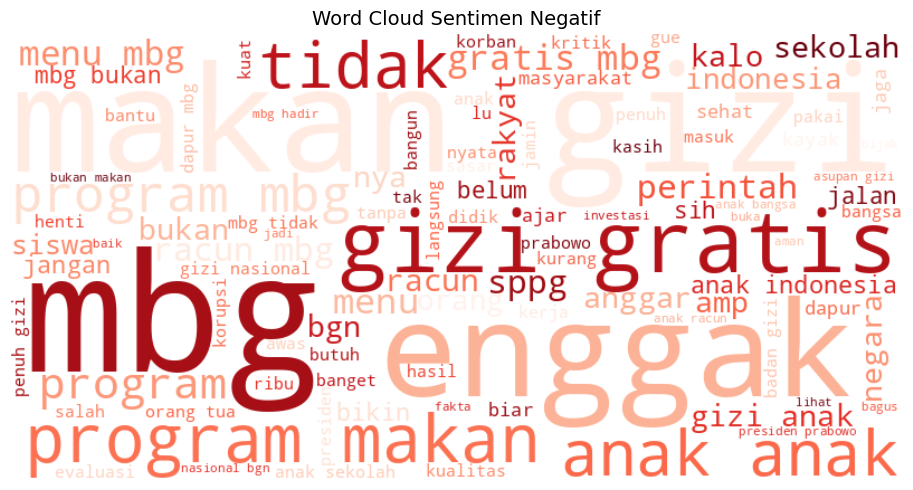

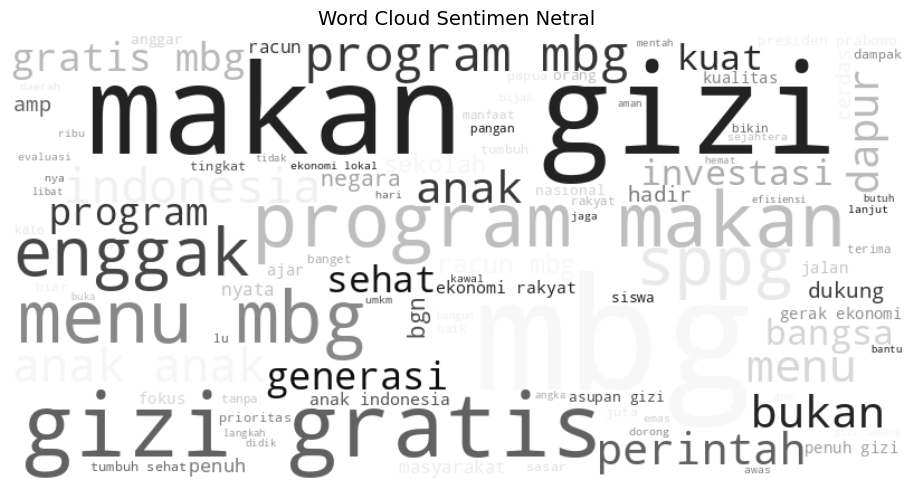

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Buat word cloud terpisah untuk tiap kelas
konfigurasi = [
    ('positif', 'Greens'),
    ('negatif', 'Reds'),
    ('netral', 'Greys')
]

for label, warna in konfigurasi:
    teks_kelas = ' '.join(df_stemming[df_stemming['label'] == label]['text_final'])

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=warna,
        max_words=100
    ).generate(teks_kelas)

    # Tiap word cloud dibuat pada figure terpisah
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud Sentimen {label.capitalize()}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/Data_TA/wordcloud_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [30]:
from collections import Counter

# Kata dominan tiap kelas sentimen
for label in ['positif', 'negatif', 'netral']:
    teks_kelas = df_stemming[df_stemming['label'] == label]['text_final']
    semua_kata = ' '.join(teks_kelas).split()
    kata_teratas = Counter(semua_kata).most_common(10)
    print(f"\n=== Kelas {label} ===")
    for kata, jml in kata_teratas:
        print(f"{kata}: {jml}")


=== Kelas positif ===
gizi: 1679
mbg: 1615
makan: 1377
program: 1134
gratis: 1048
anak: 525
sehat: 426
indonesia: 374
kualitas: 272
menu: 272

=== Kelas negatif ===
mbg: 1712
gizi: 1143
anak: 1013
makan: 940
program: 746
enggak: 425
racun: 391
gratis: 375
menu: 346
tidak: 333

=== Kelas netral ===
mbg: 268
gizi: 170
makan: 135
program: 106
anak: 101
menu: 72
gratis: 70
indonesia: 45
sehat: 40
ekonomi: 36


In [31]:
# Lihat contoh tweet negatif yang mengandung kata racun
contoh_racun = df_stemming[(df_stemming['label']=='negatif') & (df_stemming['text_final'].str.contains('racun'))]
print(contoh_racun['text_final'].head(5).to_string())

185    puluh ajar sman cisayong tasikmalaya duga racu...
207    duga racun mbg siswa sdn monggang pundong bant...
309    siswa bumil bima duga racun mbg alami mual men...
312    news siswa pondok kelapa duren sawit jakarta t...
354    siswa kawasan duren sawit duga alami racun kon...
